<a href="https://colab.research.google.com/github/IAMLATI/Time-Series-Analysis/blob/main/Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

In [2]:
df = sns.load_dataset('flights')
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [4]:
df['YearMonth'] = pd.to_datetime('01-'+ df['month'].astype(str) + ' ' + df['year'].astype(str))

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   year        144 non-null    int64         
 1   month       144 non-null    category      
 2   passengers  144 non-null    int64         
 3   YearMonth   144 non-null    datetime64[ns]
dtypes: category(1), datetime64[ns](1), int64(2)
memory usage: 4.0 KB


In [6]:
df.shape

(144, 4)

In [7]:
df['year'].unique()

array([1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959,
       1960])

In [8]:
df.set_index('YearMonth', inplace =True)

In [9]:
df.head()

,year,month,passengers
YearMonth,,,
1949-01-01,1949,Jan,112
1949-02-01,1949,Feb,118
1949-03-01,1949,Mar,132
1949-04-01,1949,Apr,129
1949-05-01,1949,May,121


<Axes: xlabel='YearMonth', ylabel='passengers'>

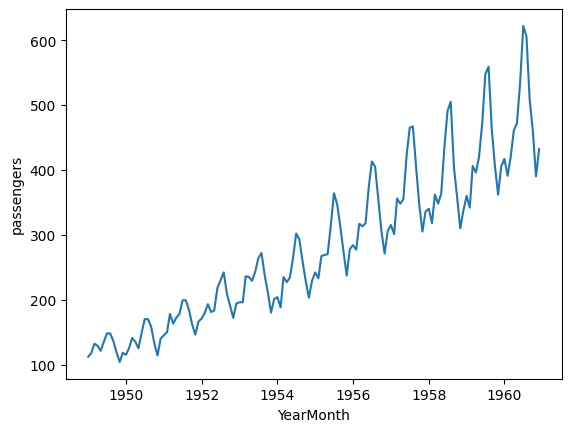

In [10]:
sns.lineplot(data = df, x = df.index, y = df.passengers)

## **Confirming if the dataset is stationary using Rolling and ADF(Augmented Dickey-Fuller)**

In [11]:
df['rollMean'] = df.passengers.rolling(window = 12).mean()
df['rollStd'] = df.passengers.rolling(window = 12).std()

<Axes: xlabel='YearMonth', ylabel='passengers'>

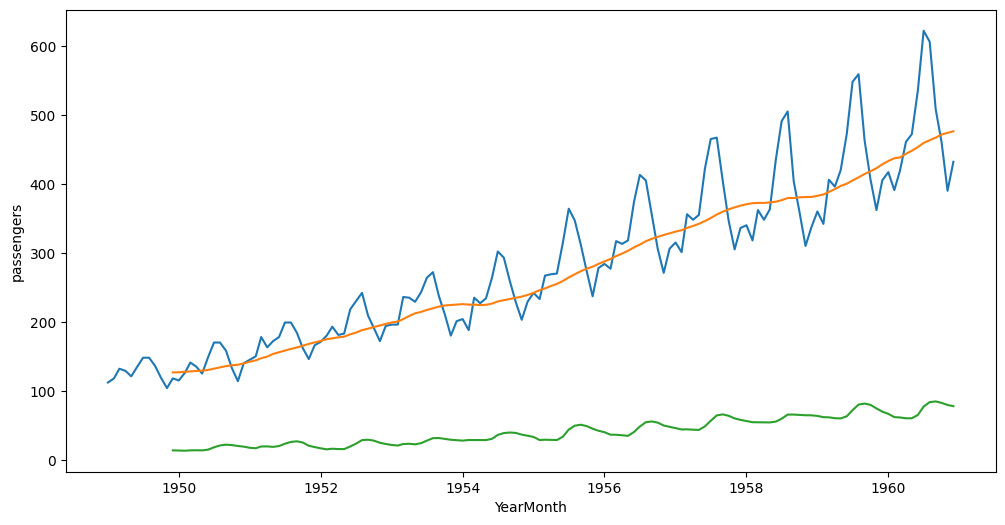

In [12]:
plt.figure(figsize =(12,6))
sns.lineplot(data = df, x = df.index, y = df.passengers)
sns.lineplot(data = df, x = df.index, y = df.rollMean)
sns.lineplot(data = df, x = df.index, y = df.rollStd)

The dataset is not stationary

In [13]:
adftest = adfuller(df['passengers'], autolag ='AIC' )

In [14]:
adftest

(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [15]:
stats = pd.Series(adftest[0:4], index = ['Test Statistic', 'P-Value', '#lags used', 'number of observation used'])
stats

,0
Test Statistic,0.815369
P-Value,0.991880
#lags used,13.000000
number of observation used,130.000000


In [16]:
for key, values in adftest[4].items():
  print('criticality', key, ':' ,values)

criticality 1% : -3.4816817173418295
criticality 5% : -2.8840418343195267
criticality 10% : -2.578770059171598


For a dataset to be stationary, test statistic < criticality

Hence, dataset is not stationary

Making a data stationery using Time shift, log, sqr root
## **New section**

In [20]:
def test_stationarity(dataFrame,var):
  dataFrame['rollMean'] = dataFrame[var].rolling(window=12).mean()
  dataFrame['rollStd'] = dataFrame[var].rolling(window=12).std()

  from statsmodels.tsa.stattools import adfuller
  adfTest = adfuller(dataFrame[var], autolag='AIC')
  stats = pd.Series(adfTest[0:4], index=['Test Statistic', 'p-value', '#lags used', 'used number of observation used'])
  print(stats)

  for key, values in adfTest[4].items():
    print("criticality" ,key, ':',values)

  sns.lineplot(data=dataFrame, x=dataFrame.index, y=var)
  sns.lineplot(data=dataFrame, x=dataFrame.index, y='rollMean')
  sns.lineplot(data=dataFrame, x=dataFrame.index, y='rollStd')

Test Statistic                       0.815369
p-value                              0.991880
#lags used                          13.000000
used number of observation used    130.000000
dtype: float64
criticality 1% : -3.4816817173418295
criticality 5% : -2.8840418343195267
criticality 10% : -2.578770059171598


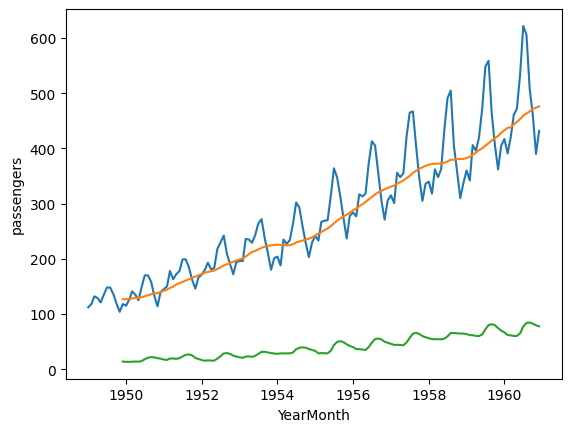

In [21]:
test_stationarity(df, 'passengers')

In [19]:
df.head()

,year,month,passengers,rollMean,rollStd
YearMonth,,,,,
1949-01-01,1949,Jan,112,NaN,NaN
1949-02-01,1949,Feb,118,NaN,NaN
1949-03-01,1949,Mar,132,NaN,NaN
1949-04-01,1949,Apr,129,NaN,NaN
1949-05-01,1949,May,121,NaN,NaN


# **Creating shift, shifting the value by a month or two, depending**

In [22]:
air_df = df[['passengers']]
air_df.head()

,passengers
YearMonth,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [24]:
air_df['shift'] = air_df.passengers.shift()
air_df['shiftDiff'] = air_df.passengers - air_df['shift']
air_df.head()

,passengers,shift,shiftDiff
YearMonth,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,112.0,6.0
1949-03-01,132,118.0,14.0
1949-04-01,129,132.0,-3.0
1949-05-01,121,129.0,-8.0


Test Statistic                      -2.829267
p-value                              0.054213
#lags used                          12.000000
used number of observation used    130.000000
dtype: float64
criticality 1% : -3.4816817173418295
criticality 5% : -2.8840418343195267
criticality 10% : -2.578770059171598


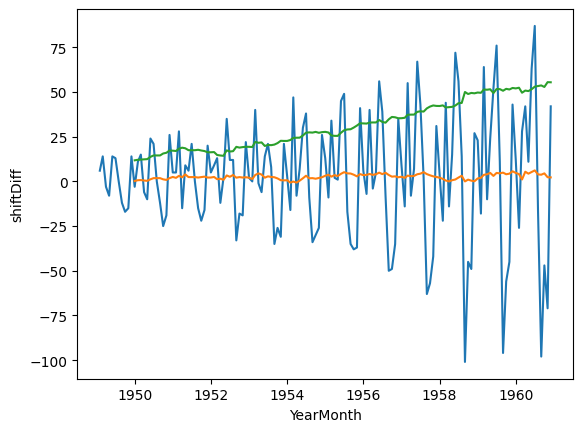

In [26]:
test_stationarity(air_df.dropna(), 'shiftDiff')

In [27]:
log_df = df[["passengers"]]
log_df['log'] = np.log(log_df['passengers'])
log_df.head()

,passengers,log
YearMonth,,
1949-01-01,112,4.718499
1949-02-01,118,4.770685
1949-03-01,132,4.882802
1949-04-01,129,4.859812
1949-05-01,121,4.795791


Test Statistic                      -1.717017
p-value                              0.422367
#lags used                          13.000000
used number of observation used    130.000000
dtype: float64
criticality 1% : -3.4816817173418295
criticality 5% : -2.8840418343195267
criticality 10% : -2.578770059171598


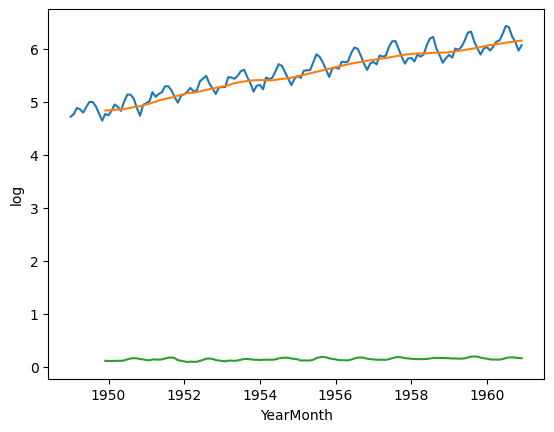

In [28]:
test_stationarity(log_df, 'log')

In [31]:
sqrt_df = df[['passengers']]
sqrt_df['sqrt'] = np.sqrt(df['passengers'])
sqrt_df.head()

,passengers,sqrt
YearMonth,,
1949-01-01,112,10.583005
1949-02-01,118,10.862780
1949-03-01,132,11.489125
1949-04-01,129,11.357817
1949-05-01,121,11.000000


Test Statistic                      -0.345854
p-value                              0.918754
#lags used                          13.000000
used number of observation used    130.000000
dtype: float64
criticality 1% : -3.4816817173418295
criticality 5% : -2.8840418343195267
criticality 10% : -2.578770059171598


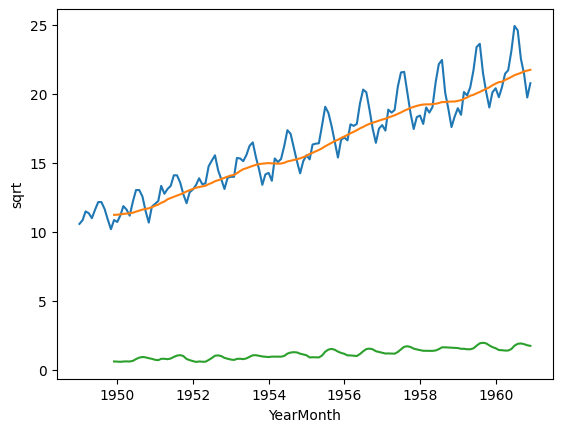

In [32]:
test_stationarity(sqrt_df, 'sqrt')

In [34]:
cbrt_df = df[['passengers']]
cbrt_df['cbrt'] = np.cbrt(df['passengers'])
cbrt_df.head()

,passengers,cbrt
YearMonth,,
1949-01-01,112,4.820285
1949-02-01,118,4.904868
1949-03-01,132,5.091643
1949-04-01,129,5.052774
1949-05-01,121,4.946087


Test Statistic                      -0.810035
p-value                              0.816157
#lags used                          13.000000
used number of observation used    130.000000
dtype: float64
criticality 1% : -3.4816817173418295
criticality 5% : -2.8840418343195267
criticality 10% : -2.578770059171598


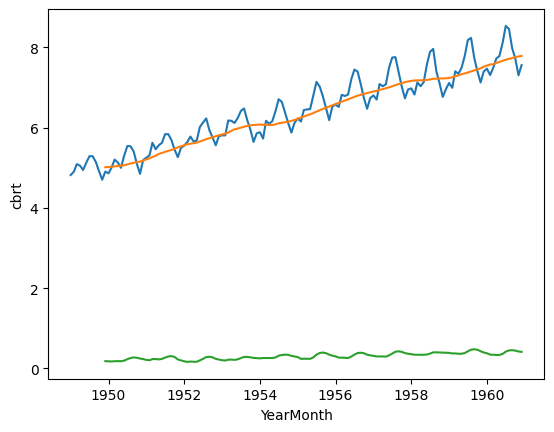

In [35]:
test_stationarity(cbrt_df, 'cbrt')

In [38]:
log_df2 = log_df[['passengers','log']]
log_df2['log_sqrt'] = np.sqrt(log_df['log'])
log_df2['log_shift_Diff']= log_df2.log_sqrt - log_df2.log_sqrt.shift()
log_df2.head()

,passengers,log,log_sqrt,log_shift_Diff
YearMonth,,,,
1949-01-01,112,4.718499,2.172211,NaN
1949-02-01,118,4.770685,2.184190,0.011979
1949-03-01,132,4.882802,2.209706,0.025517
1949-04-01,129,4.859812,2.204498,-0.005208
1949-05-01,121,4.795791,2.189929,-0.014569


Test Statistic                      -1.942528
p-value                              0.312326
#lags used                          13.000000
used number of observation used    130.000000
dtype: float64
criticality 1% : -3.4816817173418295
criticality 5% : -2.8840418343195267
criticality 10% : -2.578770059171598


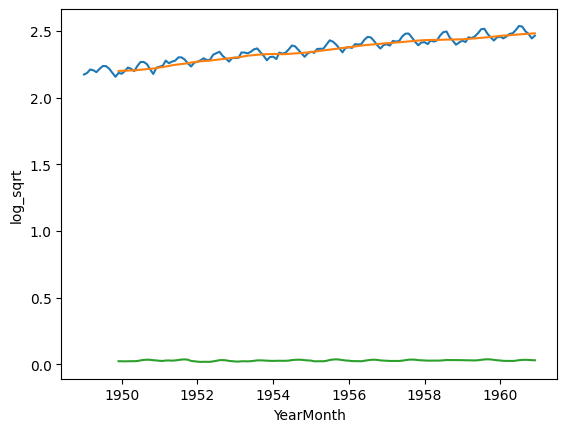

In [37]:
test_stationarity(log_df2, 'log_sqrt')

Test Statistic                      -2.611019
p-value                              0.090741
#lags used                          14.000000
used number of observation used    128.000000
dtype: float64
criticality 1% : -3.4825006939887997
criticality 5% : -2.884397984161377
criticality 10% : -2.578960197753906


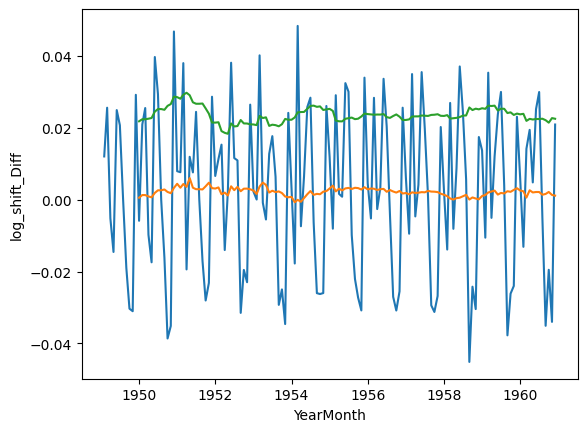

In [40]:
test_stationarity(log_df2.dropna(), 'log_shift_Diff')

In [45]:
log_df2['cbrt'] = np.cbrt(log_df2['log'])
log_df2['cbrt_shift'] = log_df2.cbrt - log_df2.cbrt.shift()
log_df2.head()


,passengers,log,log_sqrt,log_shift_Diff,cbrt,rollMean,rollStd,cbrt_shift
YearMonth,,,,,,,,
1949-01-01,112,4.718499,2.172211,NaN,1.677263,NaN,NaN,NaN
1949-02-01,118,4.770685,2.184190,0.011979,1.683424,NaN,NaN,0.006161
1949-03-01,132,4.882802,2.209706,0.025517,1.696510,NaN,NaN,0.013086
1949-04-01,129,4.859812,2.204498,-0.005208,1.693843,NaN,NaN,-0.002667
1949-05-01,121,4.795791,2.189929,-0.014569,1.686372,NaN,NaN,-0.007471


Test Statistic                      -2.015066
p-value                              0.280006
#lags used                          13.000000
used number of observation used    130.000000
dtype: float64
criticality 1% : -3.4816817173418295
criticality 5% : -2.8840418343195267
criticality 10% : -2.578770059171598


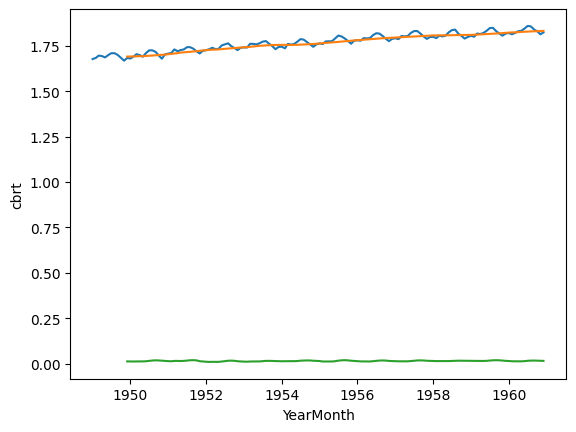

In [44]:
test_stationarity(log_df2, 'cbrt')

Test Statistic                      -3.058048
p-value                              0.029818
#lags used                          13.000000
used number of observation used    118.000000
dtype: float64
criticality 1% : -3.4870216863700767
criticality 5% : -2.8863625166643136
criticality 10% : -2.580009026141913


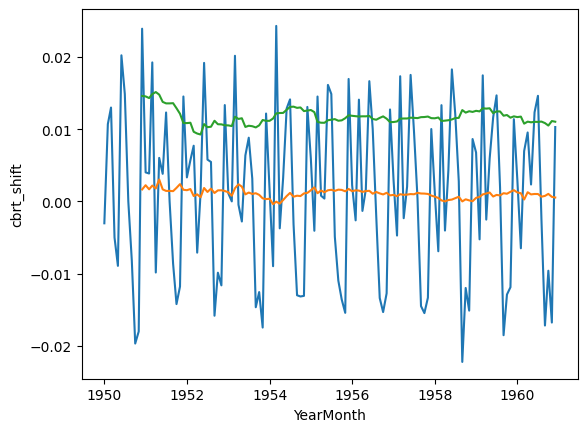

In [48]:
test_stationarity(log_df2.dropna(), 'cbrt_shift')